# Sesión 1: Diagnóstico crítico y rediseño visual

En esta sesión vamos a analizar las malas prácticas comunes en la visualización de datos y cómo corregirlas. Trabajaremos en tres fases:
1. **Taller de diagnóstico**: Identificación de errores sin pistas.
2. **Solución**: Explicación de los fallos perceptivos y matemáticos.
3. **Rediseño de alto impacto**: Aplicación de principios de diseño (foco preatencional, reducción de ruido y alineación cognitiva).

In [2]:
# ==============================================================================
# IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN INICIAL
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Establecemos un estilo limpio por defecto para eliminar fondos grises estándar
plt.style.use('default')

# Ver los estilos disponibles en Matplotlib
plt.style.available

# 1. Publicación y Medios:
#    - 'fivethirtyeight': Estilo periodístico (líneas gruesas, sin bordes, fondo tenue).
#    - 'ggplot': Estética clásica de R (fondo gris, cuadrícula blanca).
#
# 2. Familia Seaborn (Ciencia y Elegancia):
#    - 'seaborn-v0_8-whitegrid': Fondo blanco con cuadrícula (ideal para dispersión y barras).
#    - 'seaborn-v0_8-paper / poster / talk': Auto-escalan los textos según el formato final.
#
# 3. Accesibilidad:
#    - 'tableau-colorblind10': Paletas seguras y distinguibles para daltonismo.
#
# 4. Utilidades y Contraste:
#    - 'dark_background': Fondo negro (para presentaciones oscuras o modo noche).
#    - 'grayscale': Todo a escala de grises (ideal para imprimir o comprobar contraste).
#    - 'default': Restablece la configuración estándar, neutra y en blanco.


['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

## Parte 1: Taller de diagnóstico (Versión muda)
Observa los siguientes cuatro gráficos. Cada uno contiene errores graves que dificultan o engañan la percepción del espectador. ¿Puedes identificarlos?

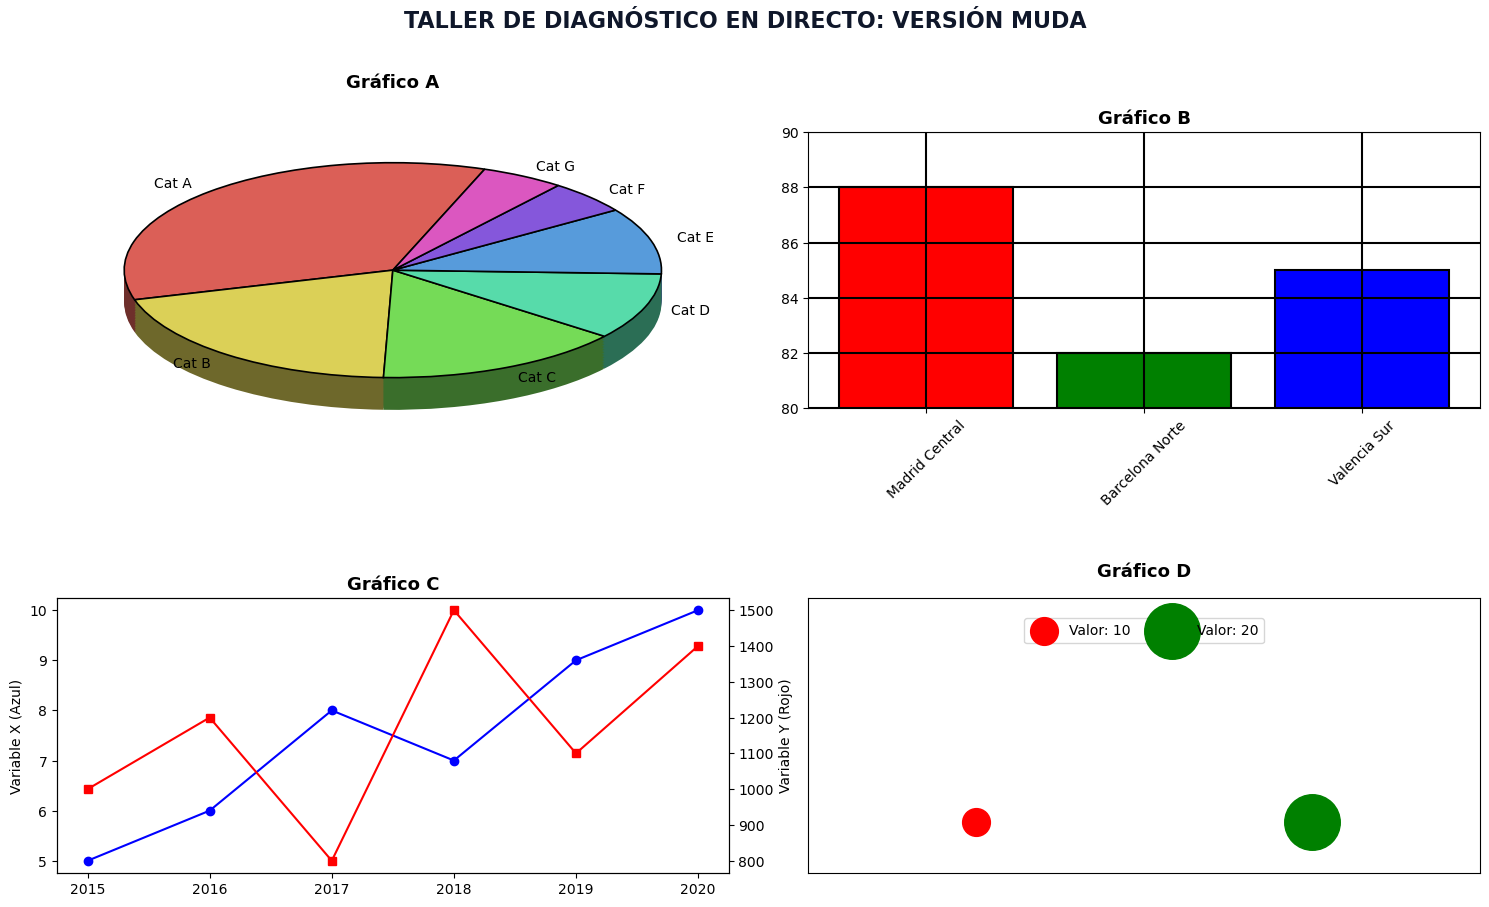

In [3]:
# ==============================================================================
# PARTE 1: TALLER DE DIAGNÓSTICO EN DIRECTO (VERSIÓN MUDA - ALUMNOS)
# ==============================================================================

# Datos de ejemplo para el pastel 3D 
valores_pie = [35, 20, 15, 10, 10, 5, 5]
categorias_pie = ['Cat A', 'Cat B', 'Cat C', 'Cat D', 'Cat E', 'Cat F', 'Cat G']

# Creamos una figura grande para albergar los 4 subgráficos
# Crea el contenedor principal (el "lienzo" o canvas) donde se alojarán todos los subgráficos.
# El parámetro figsize=(15, 9.5) define las dimensiones físicas de la figura generada.
# Los valores representan (ancho, alto) medidos en pulgadas.
# Puedes usar centímetros haciendo la conversión matemática directamente dentro del paréntesis (1 pulgada = 2.54 cm). 
# Por ejemplo, si quieres un lienzo de 38 cm de ancho por 24 cm de alto --> plt.figure(figsize=(38 / 2.54, 24 / 2.54))
fig = plt.figure(figsize=(15, 9.5))

# ------------------------------------------------------------------------------
# Gráfico A: El pastel 3D
# ------------------------------------------------------------------------------
# Crea un subgráfico dentro de la figura principal (fig).
# El código '221' significa: una cuadrícula de 2 filas, 2 columnas, y este gráfico ocupa la posición 1 
# (arriba a la izquierda).
ax1 = fig.add_subplot(221) 


# Genera una paleta de colores automática usando Seaborn (sns).
# 'hls' es un espacio de color que crea tonos vivos y equitativamente espaciados en el círculo cromático.
# len(valores_pie) asegura que se generen exactamente tantos colores como trozos tenga el gráfico circular.
colores_pie = sns.color_palette('hls', len(valores_pie))

# Oscurecemos los colores laterales para dar el efecto de sombra en el 3D
colores_laterales = [(c[0]*0.5, c[1]*0.5, c[2]*0.5) for c in colores_pie]

# Bucle de desplazamiento en el eje Y para generar el grosor físico del cilindro (3D falso)
grosor = 20
desplazamiento = 0.015
for i in range(grosor, 0, -1):
    ax1.pie(valores_pie, colors=colores_laterales, startangle=70, center=(0, -i * desplazamiento))


# Tapa superior a todo color
wedges, texts = ax1.pie(
    valores_pie,
    labels=categorias_pie,
    colors=colores_pie,
    startangle=70,
    center=(0, 0)
)
# Borde negro para separar gajos / trozos
for w in wedges:
    w.set_edgecolor('black')
    w.set_linewidth(1.2)


# Aplastamos la perspectiva para simular la elipse tridimensional (distorsiona áreas)
# Modifica la proporción (aspect ratio) entre el eje Y y el eje X del subgráfico.
# Un valor de 1.0 mantendría la proporción real (un círculo perfecto).
# Al fijarlo en 0.4, aplasta el eje vertical (altura) para que sea el 40% del eje horizontal (anchura).
# En el contexto del gráfico de pastel, esto deforma el círculo hasta convertirlo en una elipse, 
# simulando un falso efecto de perspectiva tridimensional.
ax1.set_aspect(0.4)
# pad=35: Añade un espacio (margen inferior) de 35 puntos entre el texto del título y el borde del gráfico.
ax1.set_title("Gráfico A", fontsize=13, weight='bold', pad=35)

# ------------------------------------------------------------------------------
# Gráfico B: Barras
# ------------------------------------------------------------------------------
ax2 = fig.add_subplot(222) # Cuadrícula de 2 filas, 2 columnas, y este gráfico ocupa la posición 2 (arriba a la derecha).
categorias_b = ['Madrid Central', 'Barcelona Norte', 'Valencia Sur']
valores_b = [88, 82, 85]

# Uso de colores muy saturados (RGB puros) 
ax2.bar(categorias_b, valores_b, color=['red', 'green', 'blue'], edgecolor='black', linewidth=1.5)
# Eje Y truncado: No nace en 0
ax2.set_ylim(80, 90)
# Cuadrícula
# '-' o 'solid'   : Línea continua y sólida (por defecto).
# '--' o 'dashed' : Línea discontinua (a trazos).
# ':' o 'dotted'  : Línea punteada (formada por pequeños puntos).
# '-.' o 'dashdot': Línea que alterna un trazo y un punto.
# '' o 'None'     : Línea invisible (para ocultar bordes o cuadrículas).
ax2.grid(color='black', linestyle='-', linewidth=1.5)
# Etiquetas inclinadas
ax2.tick_params(axis='x', rotation=45)
ax2.set_title("Gráfico B", fontsize=13, weight='bold')

# ------------------------------------------------------------------------------
# Gráfico C: Doble eje Y
# ------------------------------------------------------------------------------
ax3 = fig.add_subplot(223) # Cuadrícula de 2 filas, 2 columnas, y este gráfico ocupa la posición 3 (abajo a la izquierda).
# Crea un array con una secuencia de números usando la librería NumPy (np)
# El primer parámetro (2015) es el valor de inicio (inclusivo).
# El segundo parámetro (2021) es el límite final (exclusivo, no se incluye en la serie).
# Resultado: genera la secuencia de años [2015, 2016, 2017, 2018, 2019, 2020].
t = np.arange(2015, 2021) 
v1 = [5, 6, 8, 7, 9, 10]
v2 = [1000, 1200, 800, 1500, 1100, 1400]

# Primera serie en el eje izquierdo
# Tipos de 'marker' (marcador) disponibles en Matplotlib:
# 'o' : Círculo
# '.' : Punto (mucho más pequeño y sutil que el círculo)
# 's' : Cuadrado (Square)
# 'D' : Diamante (Diamond)
# '^' : Triángulo apuntando hacia arriba
# 'v' : Triángulo apuntando hacia abajo
# '<' : Triángulo apuntando hacia la izquierda
# '>' : Triángulo apuntando hacia la derecha
# '*' : Estrella
# '+' : Cruz ortogonal (signo de suma)
# 'x' : Cruz diagonal (equis)
# 'p' : Pentágono
# 'h' : Hexágono
# '' o 'None': Sin marcador (solo dibuja la línea continua)
ax3.plot(t, v1, color='blue', marker='o')
ax3.set_ylabel('Variable X (Azul)')

# Segunda serie en el eje derecho 
# twinx() crea un segundo eje Y ("gemelo") que comparte exactamente el mismo eje X que el gráfico original (ax3).
# La función 'twinx()' genera esta nueva escala vertical independiente y la coloca en el lado derecho de la figura.
# Esto permite dibujar una segunda serie de datos con magnitudes o unidades completamente distintas en el mismo lienzo / canvas.
ax3_twin = ax3.twinx()
ax3_twin.plot(t, v2, color='red', marker='s')
ax3_twin.set_ylabel('Variable Y (Rojo)')
ax3.set_title("Gráfico C", fontsize=13, weight='bold')

# ------------------------------------------------------------------------------
# Gráfico D: Tamaño proporcional
# ------------------------------------------------------------------------------
ax4 = fig.add_subplot(224) # Cuadrícula de 2 filas, 2 columnas, y este gráfico ocupa la posición 4 (abajo a la derecha).
# Mapear datos al diámetro (s en scatter es el área del marcador, no el radio)
# Aquí, el radio 'r' pasa a '2r')
#   1. Fórmula r        : Area_1 = pi * r^2
#   2. Fórmula 2r       : Area_2 = pi * (2r)^2
#   3. Desarrollo       : Area_2 = pi * 4 * r^2
#   4. Resultado final  : Area_2 = 4 * (pi * r^2)
# Conclusión: Al duplicar el radio, el área crece 4 veces.
# Por tanto, si usamos s=400 para el valor 10, tenemos s=1600 para el valor 20
ax4.scatter(1, 1.5, s=400, color='red', label='Valor: 10')
ax4.scatter(3, 1.5, s=1600, color='green', label='Valor: 20')
ax4.set_xlim(0, 4) # Define los límites visibles del eje X (empieza en 0 y termina en 4).
ax4.set_ylim(0, 8) # Define los límites visibles del eje Y (desde 0 hasta 8).
ax4.set_yticks([]) # Oculta todas las marcas (rayitas) y las etiquetas numéricas del eje vertical (Y) pasándole una lista vacía.
ax4.set_xticks([]) # Oculta todas las marcas y las etiquetas numéricas del eje horizontal (X), dejando un fondo completamente puro.
# Leyenda desconectada visualmente
ax4.legend(loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=2)
ax4.set_title("Gráfico D", fontsize=13, weight='bold', pad=15)

# Ajustes finales de la figura
# "Súper Título" (suptitle) global
plt.suptitle("TALLER DE DIAGNÓSTICO EN DIRECTO: VERSIÓN MUDA", fontsize=16, weight='bold', color='#0F172A')

# tight_layout evita que los títulos y ejes se superpongan
# Este recalcula y ajusta automáticamente las posiciones de los ejes 
# y los subgráficos para que no se superpongan los textos ni las etiquetas.
# - rect=[izq, abajo, dcha, arriba]: Define el área útil del lienzo (de 0 a 1). 
#   Al fijar el 'arriba' en 0.93, estamos dejando un 7% del espacio libre en la 
#   parte superior exclusivamente para que el 'suptitle' respire y no aplaste 
#   a los títulos individuales de la primera fila de gráficos.
# - h_pad=4.0: Añade un "colchón" extra de espacio vertical (height padding) 
#   entre las diferentes filas de subgráficos para evitar que el título de los 
#   gráficos de abajo choque con el eje X de los gráficos de arriba.
plt.tight_layout(rect=[0, 0.03, 1, 0.93], h_pad=4.0)

# Es la orden final que "imprime" el lienzo en la pantalla. 
# Si ejecutas esto en un script de Python tradicional, el programa se pausará 
# en esta línea mostrando una ventana interactiva. El código solo continuará 
# ejecutándose cuando el usuario cierre dicha ventana manualmente (en un script de Python).
plt.show()


## Parte 2: Solución
A continuación, revelamos por qué los gráficos anteriores fallan en comunicar la realidad de los datos basándonos en las reglas de la visualización.

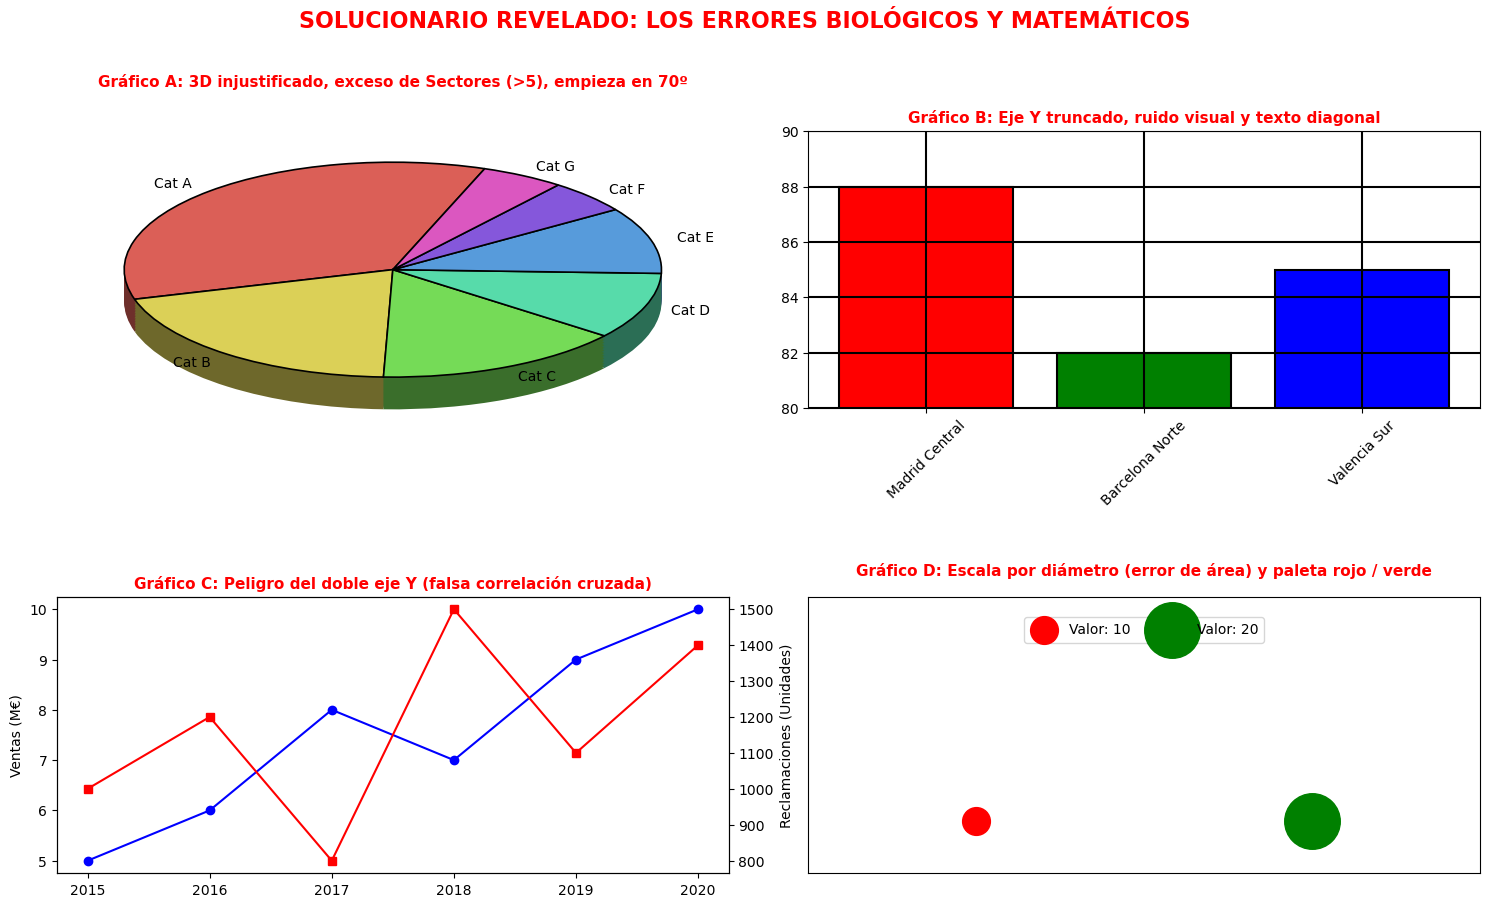

In [4]:
# ==============================================================================
# PARTE 2: EL SOLUCIONARIO DE DIAGNÓSTICO (VERSIÓN REVELADA)
# ==============================================================================
fig_sol = plt.figure(figsize=(15, 9.5))

# --- Solución Gráfico A ---
ax1_sol = fig_sol.add_subplot(221)
for i in range(grosor, 0, -1):
    ax1_sol.pie(valores_pie, colors=colores_laterales, startangle=70, center=(0, -i * desplazamiento))
    
wedges, texts = ax1_sol.pie(valores_pie, labels=categorias_pie, colors=colores_pie, startangle=70, center=(0, 0))

for w in wedges:
    w.set_edgecolor('black')
    w.set_linewidth(1.2)
ax1_sol.set_aspect(0.4)

# Explicación: El 3D distorsiona las áreas reales. Además, más de 5 sectores saturan la memoria de trabajo.
ax1_sol.set_title("Gráfico A: 3D injustificado, exceso de Sectores (>5), empieza en 70º", fontsize=11, weight='bold', color='red', pad=35)

# --- Solución Gráfico B ---
ax2_sol = fig_sol.add_subplot(222)
ax2_sol.bar(categorias_b, valores_b, color=['red', 'green', 'blue'], edgecolor='black', linewidth=1.5)
ax2_sol.set_ylim(80, 90)
ax2_sol.grid(color='black', linestyle='-', linewidth=1.5)
ax2_sol.tick_params(axis='x', rotation=45)
# Explicación: Romper el eje Y (no empezar en cero) miente visualmente. El texto rotado aumenta la fatiga cognitiva.
ax2_sol.set_title("Gráfico B: Eje Y truncado, ruido visual y texto diagonal", fontsize=11, weight='bold', color='red')

# --- Solución Gráfico C ---
ax3_sol = fig_sol.add_subplot(223)
ax3_sol.plot(t, v1, color='blue', marker='o')
ax3_sol.set_ylabel('Ventas (M€)')
ax3_twin_sol = ax3_sol.twinx()
ax3_twin_sol.plot(t, v2, color='red', marker='s')
ax3_twin_sol.set_ylabel('Reclamaciones (Unidades)')
# Explicación: Las escalas cruzadas permiten manipular los cruces de líneas, sugiriendo correlaciones que no existen.
ax3_sol.set_title("Gráfico C: Peligro del doble eje Y (falsa correlación cruzada)", fontsize=11, weight='bold', color='red')

# --- Solución Gráfico D ---
ax4_sol = fig_sol.add_subplot(224)
ax4_sol.scatter(1, 1.5, s=400, color='red', label='Valor: 10')
ax4_sol.scatter(3, 1.5, s=1600, color='green', label='Valor: 20')
ax4_sol.set_xlim(0, 4)
ax4_sol.set_ylim(0, 8)
ax4_sol.set_yticks([])
ax4_sol.set_xticks([])
ax4_sol.legend(loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=2)
# Explicación: Si el valor se duplica (10 a 20) pero se escala por radio/diámetro, el área crece x4. La paleta rojo/verde perjudica a personas con daltonismo.
ax4_sol.set_title("Gráfico D: Escala por diámetro (error de área) y paleta rojo / verde", fontsize=11, weight='bold', color='red', pad=15)

plt.suptitle("SOLUCIONARIO REVELADO: LOS ERRORES BIOLÓGICOS Y MATEMÁTICOS", fontsize=16, weight='bold', color='red')
plt.tight_layout(rect=[0, 0.03, 1, 0.93], h_pad=4.0)
plt.show()


## Parte 3: Rediseño de alto impacto
Ahora aplicaremos las buenas prácticas para lograr un gráfico impecable. Utilizaremos el principio de **Foco Preatencional** (guiando el ojo al dato importante), eliminaremos la "tinta no relacionada con los datos" (marcos y cuadrículas) y facilitaremos la lectura occidental.

No se pudo cargar el CSV. Usando datos de respaldo (mock).
Colores asignados a las barras: ['#D32F2F', '#94A3B8', '#94A3B8', '#94A3B8', '#94A3B8']


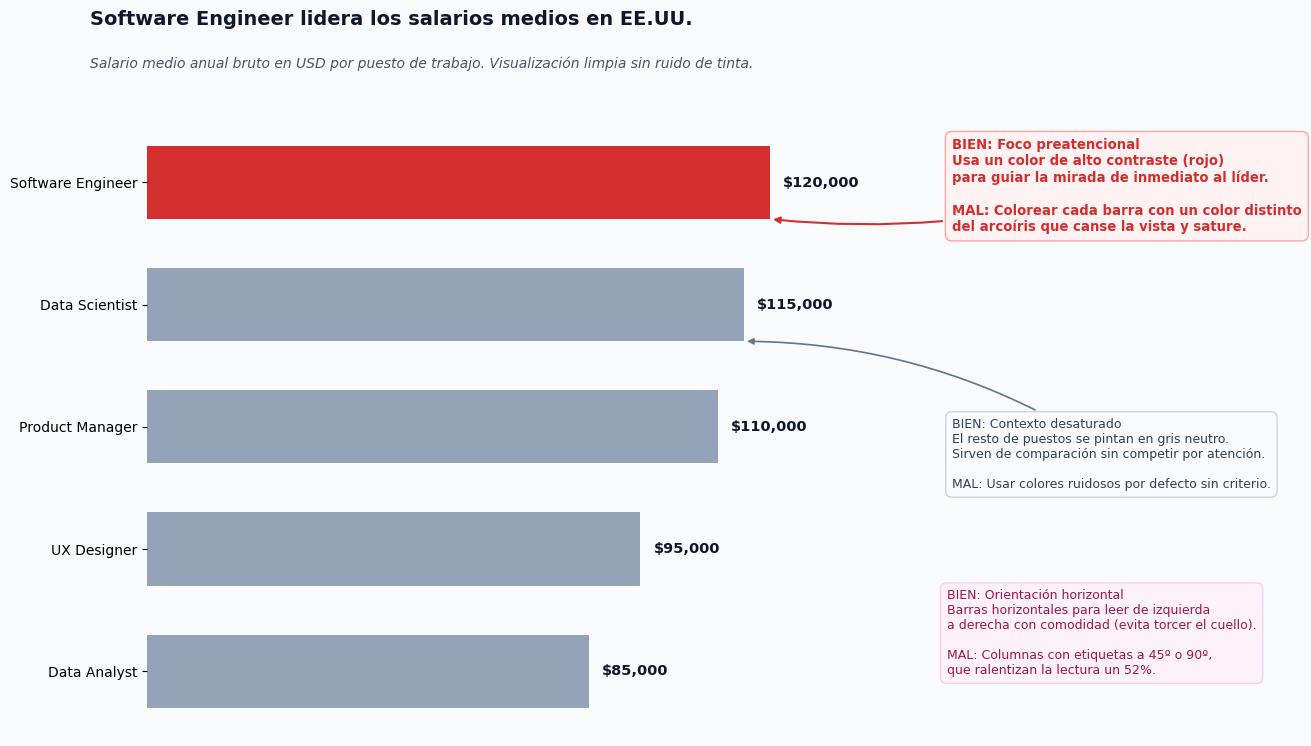

In [ ]:
# ==============================================================================
# PARTE 3: EL REDISEÑO DE ALTO IMPACTO (EL GRÁFICO IMPECABLE)
# ==============================================================================
# import os
# print(os.getcwd())

    
# 1. Carga de datos reales o simulación de respaldo
try:
    df_salary = pd.read_csv('usa-salary.csv')
    df_grouped = df_salary.groupby('Job Title')['Salary'].mean().reset_index()
    # Ordenamos de mayor a menor para facilitar la jerarquía visual
    df_grouped = df_grouped.sort_values(by='Salary', ascending=False)
except Exception:
    print("No se pudo cargar el CSV. Usando datos de respaldo (mock).")
    # Datos de respaldo (mock) en caso de que no exista el CSV o columnas faltantes.
    respaldo = {
        'Job Title': ['Software Engineer', 'Data Scientist', 'Product Manager', 'UX Designer', 'Data Analyst'],
        'Salary': [120000, 115000, 110000, 95000, 85000]
    }
    df_grouped = pd.DataFrame(respaldo).sort_values(by='Salary', ascending=False)

# 2. Configuración del lienzo limpio
fig_ok, ax_ok = plt.subplots(figsize=(13.5, 7.5), facecolor='#F8FAFC')
# Pinta el recuadro interior exactamente del mismo color.
ax_ok.set_facecolor('#F8FAFC')

# 3. Paleta de colores estratégica
HIGHLIGHT_RED = '#D32F2F' # Acento para captar la atención de inmediato
NEUTRAL_GRAY = '#94A3B8'  # Gris desaturado para el resto (contexto, sin ruido)
TEXT_COLOR = '#0F172A'    # Contraste alto para textos legibles

# Pintamos SOLO el ganador en rojo, el resto queda en un segundo plano cognitivo
colores_bar = [HIGHLIGHT_RED] + [NEUTRAL_GRAY] * (len(df_grouped) - 1) # ['#D32F2F', '#94A3B8', '#94A3B8', '#94A3B8', '#94A3B8']
print(f"Colores asignados a las barras: {colores_bar}")
# Bar plot horizontal con altura de barra ajustada a 0.6 para mayor claridad visual
bars = ax_ok.barh(df_grouped['Job Title'], df_grouped['Salary'], color=colores_bar, height=0.6)

# Invertimos el eje Y para leer el mayor valor arriba (lectura occidental Z)
ax_ok.invert_yaxis()

# 4. Reducción drástica del "Data-Ink Ratio" (Tufte)
# Eliminamos marcos (spine / espina / linea de borde derecha, superior e inferior)
# Por defecto, si pones sns.despine() sin parámetros, elimina automáticamente el borde 
# superior y el derecho. Al añadir los parámetros (left=True, bottom=True), forzamos a 
# que también desaparezcan la línea del eje Y (izquierdo) y del eje X (inferior).
sns.despine(left=True, bottom=True)
ax_ok.get_xaxis().set_visible(False) # Quitamos el eje X completo (ya pondremos las etiquetas directas)
ax_ok.spines['left'].set_color('#E2E8F0')

# Ampliamos el lienzo derecho para dar respiro visual y poner notas explicativas
ax_ok.set_xlim(0, 220000) # Valores en X (dolares) para que las barras no se corten y haya espacio para anotaciones

# 5. Etiquetas directas (Gestalt: Ley de proximidad)
# Colocamos el valor exacto al final de la barra, evitando que el ojo viaje al eje X
for bar in bars:
    width = bar.get_width()
    # f'${width:,.0f}' es un f-string de Python para formatear números.
    #   - '$': Pinta el símbolo del dólar literalmente.
    #   - ',': Añade la coma como separador de miles (ej: 120,000).
    #   - '.0f': Le dice que use 0 decimales (f = float), redondeando el número.
    ax_ok.text(width + 2500, bar.get_y() + bar.get_height()/2,
               f'${width:,.0f}', ha='left', va='center',
               fontsize=10.5, fontweight='bold', color=TEXT_COLOR)

# 6. Anotaciones
# Nota 1: Foco preatencional

# FUNCIÓN ANNOTATE (Caja de texto + flecha indicadora)
# xy: COORDENADA DEL OBJETIVO (A DÓNDE APUNTA LA FLECHA)
# df_grouped['Salary'].iloc[0] saca el valor numérico (X) de la barra más alta.
# El 0.3 es la altura (Y). Si la primera barra está en Y=0, el 0.3 hace 
# que la flecha apunte ligeramente por encima de la base.
# xytext: COORDENADA DE LA CAJA DE TEXTO (DÓNDE NACE LA FLECHA)
# 155000 coloca el texto muy a la derecha, en la zona blanca
# que creamos antes con set_xlim.
# Propiedades de la flecha:
# arrowstyle="-|>",                  # Forma de la flecha: línea que acaba en triángulo relleno.
# connectionstyle="arc3,rad=-0.1",   # Hace que la flecha sea curva (rad controla cuánto se curva).
# color=HIGHLIGHT_RED,               # Color de la flecha.
# lw=1.5                             # lw (Line Width): Grosor de la línea.
# El parámetro 'connectionstyle' le dice a la flecha cómo viajar 
# desde el texto hasta el dato. Existen 5 "familias" principales:
# 1. LA CURVA SIMPLE ("arc3") --> La más elegante y usada.
#    Traza una curva directa y continua.
#    - rad: Controla la comba (0 = recta, 0.2 = curva suave, -0.2 = curva inversa).
#    * Sintaxis: connectionstyle="arc3,rad=0.2"
# 2. EL CODO O ÁNGULO RECTO ("angle") --> Ideal para gráficos técnicos.
#    Dibuja una línea que gira bruscamente (como una tubería o un codo).
#    - angleA: Ángulo de salida desde el texto (ej. 0 = horizontal).
#    - angleB: Ángulo de llegada al punto (ej. 90 = vertical).
#    - rad: Redondea la esquina del codo para suavizarla (ej. 5).
#    * Sintaxis: connectionstyle="angle,angleA=0,angleB=90,rad=5"
# 3. LA CURVA DIRIGIDA ("angle3")
#    Dibuja una curva suave, pero en lugar de que el programa decida el 
#    camino, tú fuerzas los ángulos exactos de salida y entrada.
#    * Sintaxis: connectionstyle="angle3,angleA=0,angleB=-90"
# 4. EL CORCHETE ORTOGONAL ("bar") --> Muy útil en estadística.
#    Dibuja líneas cuadradas simulando un corchete [ o ].
#    Se usa muchísimo para agrupar varias barras y ponerles un texto común 
#    (ej. "Estos 3 valores suman el 80%").
#    - fraction: Define cuánto sobresale el brazo del corchete.
#    * Sintaxis: connectionstyle="bar,fraction=0.2"
# 5. CURVA CON BRAZOS ("arc")
#    Saca una línea recta desde el texto y otra línea recta desde el dato 
#    (los brazos) y luego conecta esas dos rectas con una curva central.
#    * Sintaxis: connectionstyle="arc,angleA=0,angleB=90,armA=20,armB=20"

# (Bounding Box): PROPIEDADES DEL RECUADRO DE FONDO (bbox)
# boxstyle="round,pad=0.5",  # Forma redonda con 'pad' (margen interior) de 0.5.
# fc="#FEF2F2",              # fc (Face Color): Color de fondo del recuadro.
# ec="#FCA5A5",              # ec (Edge Color): Color de la línea del borde.
# lw=1                       # lw (Line Width): Grosor del borde del recuadro.
ax_ok.annotate(
    "BIEN: Foco preatencional\n"
    "Usa un color de alto contraste (rojo)\n"
    "para guiar la mirada de inmediato al líder.\n\n"
    "MAL: Colorear cada barra con un color distinto\n"
    "del arcoíris que canse la vista y sature.",
    xy=(df_grouped['Salary'].iloc[0], 0.3),  
    xytext=(155000, 0.4),  
    arrowprops=dict(
        arrowstyle="-|>", 
        connectionstyle="arc3,rad=-0.1", 
        color=HIGHLIGHT_RED, 
        lw=1.5
    ),
    fontsize=9.5, color=HIGHLIGHT_RED, fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.5", fc="#FEF2F2", ec="#FCA5A5", lw=1)
)

# Nota 2: Desaturación
ax_ok.annotate(
    "BIEN: Contexto desaturado\n"
    "El resto de puestos se pintan en gris neutro.\n"
    "Sirven de comparación sin competir por atención.\n\n"
    "MAL: Usar colores ruidosos por defecto sin criterio.",
    xy=(df_grouped['Salary'].iloc[1], 1.3),  
    xytext=(155000, 2.5),  
    arrowprops=dict(
        arrowstyle="-|>", 
        connectionstyle="arc3,rad=0.15", 
        color='#64748B', 
        lw=1.2
    ),
    fontsize=9, color='#334155',
    bbox=dict(boxstyle="round,pad=0.5", fc="#F8FAFC", ec="#CBD5E1", lw=1)
)

# Nota 3: Orientación horizontal

# FUNCIÓN TEXT (Solo Texto)
# Se usa cuando simplemente quieres poner una caja de texto flotante
# sin ninguna flecha que lo conecte a los datos.
# 155000, 4.6, # Coordenadas X e Y directas donde se anclará la caja de texto.
ax_ok.text(
    # 155000, 4.6,
    # X = 0.70 (Coloca el texto en el 70% del ancho del gráfico)
    # Y = 0.90 (Coloca el texto en el 90% de la altura, casi arriba del todo)
    0.70, 0.10, 
    "BIEN: Orientación horizontal\n"
    "Barras horizontales para leer de izquierda\n"
    "a derecha con comodidad (evita torcer el cuello).\n\n"
    "MAL: Columnas con etiquetas a 45º o 90º,\n"
    "que ralentizan la lectura un 52%.",
    # 'transform' le dice que no use los datos reales (salarios),
    # sino el sistema de coordenadas de los ejes (de 0.0 a 1.0).
    transform=ax_ok.transAxes,
    fontsize=9, color='#9D174D',
    bbox=dict(boxstyle="round,pad=0.5", fc="#FDF2F8", ec="#FBCFE8", lw=1)
)


# 7. Títulos con jerarquía (Título explícito + Subtítulo de contexto)
ax_ok.text(-0.05, 1.15, 'Software Engineer lidera los salarios medios en EE.UU.',
           transform=ax_ok.transAxes, fontsize=14, fontweight='bold', color=TEXT_COLOR)
ax_ok.text(-0.05, 1.08, 'Salario medio anual bruto en USD por puesto de trabajo. Visualización limpia sin ruido de tinta.',
           transform=ax_ok.transAxes, fontsize=10, color='#475569', style='italic')

plt.tight_layout()
plt.show()
